In [8]:
import json

import gc_utils
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter

In [9]:
sim_dir = "/Users/z5114326/Documents/simulations/"

it_min = 0
it_max = 100

pub_data = sim_dir + "snapshot_times_public.txt"
pub_snaps = pd.read_table(pub_data, comment="#", header=None, sep=r"\s+")
pub_snaps.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]

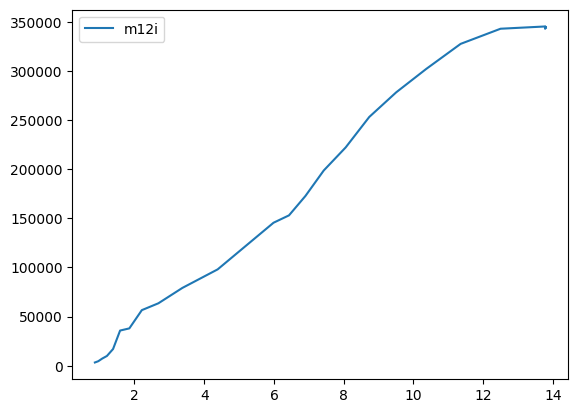

In [10]:
sim_lst = ["m12b", "m12c", "m12f", "m12i", "m12m"]
snap_lim_lst = [46, 46, 46, 46, 102]

sim_lst = ["m12i"]
snap_lim_lst = [46]

cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in np.linspace(0, 1, len(sim_lst))]

sim = "m12i"
snap_lim = 46


# for
# et = proc_data["it000"]["snapshots"]["snap600"]["et"][()]

for i, sim in enumerate(sim_lst):
    proc_file = sim_dir + sim + "/" + sim + "_processed.hdf5"
    proc_data = h5py.File(proc_file, "r")  # open processed data file

    t = []
    d = []
    for snap_id in proc_data["it000"]["snapshots"].keys():
        snap = int(snap_id[4:])
        if snap < snap_lim_lst[i]:
            continue
        time = pub_snaps[pub_snaps["index"] == snap]["time_Gyr"].values[0]
        t.append(time)

        et = proc_data["it000"]["snapshots"][snap_id]["et"][()]
        et_norm = proc_data["it000"]["snapshots"][snap_id]["et_norm"][()]
        depths = et / et_norm

        d.append(depths[0])

    plt.plot(t, d, c=colors[i], label=sim)
plt.legend()

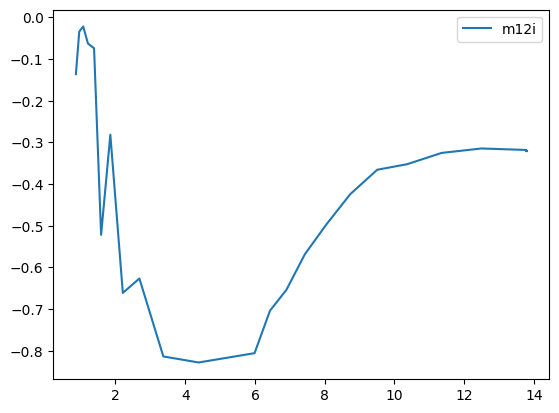

In [12]:
for i, sim in enumerate(sim_lst):
    proc_file = sim_dir + sim + "/" + sim + "_processed.hdf5"
    proc_data = h5py.File(proc_file, "r")  # open processed data file

    t = []
    d = []
    for snap_id in proc_data["it000"]["snapshots"].keys():
        snap = int(snap_id[4:])
        if snap < snap_lim_lst[i]:
            continue
        time = pub_snaps[pub_snaps["index"] == snap]["time_Gyr"].values[0]
        t.append(time)

        msk = proc_data["it000"]["snapshots"][snap_id]["bound_flag"][()] == 1

        et = proc_data["it000"]["snapshots"][snap_id]["et"][msk]
        et_norm = proc_data["it000"]["snapshots"][snap_id]["et_norm"][msk]

        d.append(np.median(et_norm))

    plt.plot(t, d, c=colors[i], label=sim)
plt.legend()

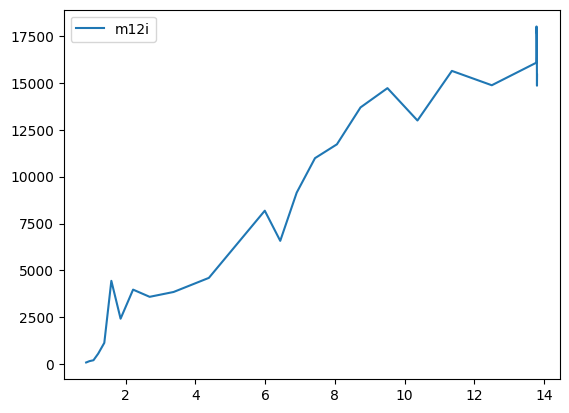

In [16]:
for i, sim in enumerate(sim_lst):
    proc_file = sim_dir + sim + "/" + sim + "_processed.hdf5"
    proc_data = h5py.File(proc_file, "r")  # open processed data file

    t = []
    d = []
    for snap_id in proc_data["it000"]["snapshots"].keys():
        snap = int(snap_id[4:])
        if snap < snap_lim_lst[i]:
            continue
        time = pub_snaps[pub_snaps["index"] == snap]["time_Gyr"].values[0]
        t.append(time)

        msk = proc_data["it000"]["snapshots"][snap_id]["bound_flag"][()] == 1

        ek = proc_data["it000"]["snapshots"][snap_id]["ek"][msk]

        d.append(np.median(ek))

    plt.plot(t, d, c=colors[i], label=sim)
plt.legend()

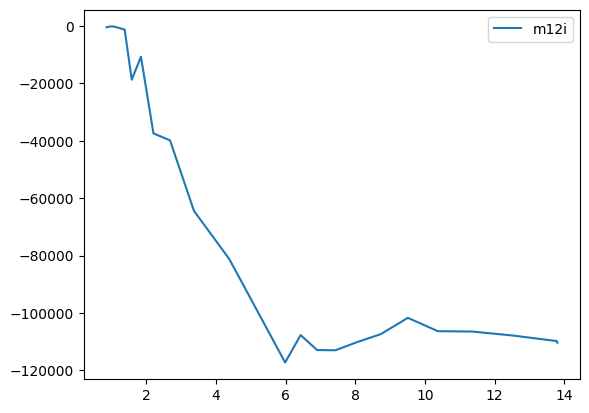

In [11]:
for i, sim in enumerate(sim_lst):
    proc_file = sim_dir + sim + "/" + sim + "_processed.hdf5"
    proc_data = h5py.File(proc_file, "r")  # open processed data file

    t = []
    d = []
    for snap_id in proc_data["it000"]["snapshots"].keys():
        snap = int(snap_id[4:])
        if snap < snap_lim_lst[i]:
            continue
        time = pub_snaps[pub_snaps["index"] == snap]["time_Gyr"].values[0]
        t.append(time)

        msk = proc_data["it000"]["snapshots"][snap_id]["bound_flag"][()] == 1

        et = proc_data["it000"]["snapshots"][snap_id]["et"][msk]
        et_norm = proc_data["it000"]["snapshots"][snap_id]["et_norm"][msk]

        d.append(np.median(et))

    plt.plot(t, d, c=colors[i], label=sim)
plt.legend()

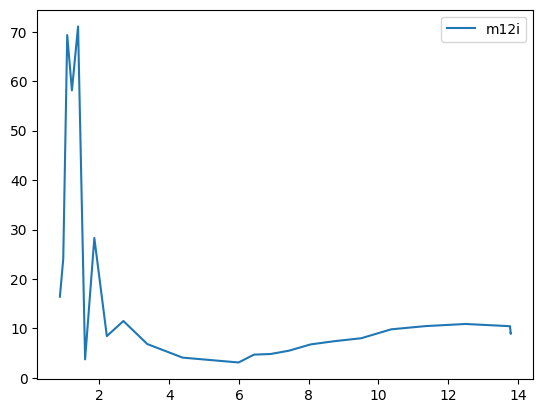

In [13]:
for i, sim in enumerate(sim_lst):
    proc_file = sim_dir + sim + "/" + sim + "_processed.hdf5"
    proc_data = h5py.File(proc_file, "r")  # open processed data file

    t = []
    d = []
    for snap_id in proc_data["it000"]["snapshots"].keys():
        snap = int(snap_id[4:])
        if snap < snap_lim_lst[i]:
            continue
        time = pub_snaps[pub_snaps["index"] == snap]["time_Gyr"].values[0]
        t.append(time)

        msk = proc_data["it000"]["snapshots"][snap_id]["bound_flag"][()] == 1

        et = proc_data["it000"]["snapshots"][snap_id]["r"][msk]
        et_norm = proc_data["it000"]["snapshots"][snap_id]["et_norm"][msk]

        d.append(np.median(et))

    plt.plot(t, d, c=colors[i], label=sim)
plt.legend()

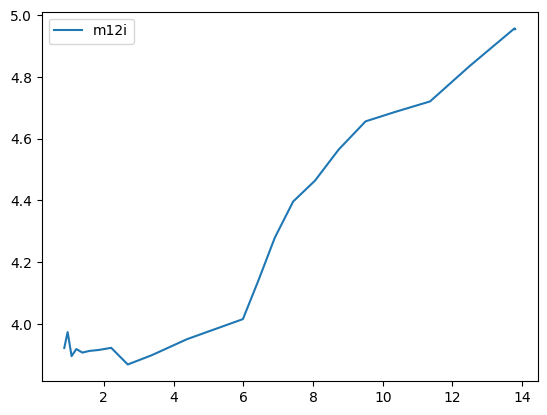

In [14]:
for i, sim in enumerate(sim_lst):
    proc_file = sim_dir + sim + "/" + sim + "_processed.hdf5"
    proc_data = h5py.File(proc_file, "r")  # open processed data file

    t = []
    d = []
    for snap_id in proc_data["it000"]["snapshots"].keys():
        snap = int(snap_id[4:])
        if snap < snap_lim_lst[i]:
            continue
        time = pub_snaps[pub_snaps["index"] == snap]["time_Gyr"].values[0]
        t.append(time)

        msk = proc_data["it000"]["snapshots"][snap_id]["bound_flag"][()] == 1

        et = proc_data["it000"]["snapshots"][snap_id]["mass"][msk]
        et_norm = proc_data["it000"]["snapshots"][snap_id]["et_norm"][msk]

        d.append(np.median(et))

    plt.plot(t, d, c=colors[i], label=sim)
plt.legend()